# Semantic Engagement Analysis

The goal of this notebook is to measure how video performance depends on the semantic space per channel.
Instead of measuring by cluster, we aim to:
1. Find the point where engagement is optimal per channel.
2. Measure the correlation between distance to this optimal point and engagement.
3. Order channels by engagement predictability.
4. Provide plots to complement the measurement.

## 1) Install dependencies and connect to MongoDB
This step installs the required packages and connects to MongoDB if needed, though primarily we'll be using `pandas`, `numpy`, and `matplotlib`/`seaborn` along with `scikit-learn` or `scipy` for distance computation.

In [1]:
# Install runtime dependencies
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels nbformat

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.spatial.distance import cdist
from pathlib import Path

# Set up matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not in Colab, skipping drive mount')



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


Not in Colab, skipping drive mount


## 2) Load the 20D video embeddings
According to coding guidelines, we import the 20D video embeddings from the canonical path. This artifact contains original 20-dimensional embeddings for each video. We will then clean the data by filtering out missing view counts and calculating the logarithm of view counts (`log_views`) to handle the power-law distribution of engagement.

In [2]:
DATA_PATH = Path('/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv')

# Note: Since this is meant to be run in Colab, we provide a mock/fallback for testing in local environment if the path doesn't exist.
if not DATA_PATH.exists():
    print(f"Warning: {DATA_PATH} not found. Attempting to run with dummy data or fallback if available, or this notebook will fail when executed locally.")

# Read the data
if DATA_PATH.suffix.lower() == '.csv':
    try:
        df = pd.read_csv(DATA_PATH)
    except FileNotFoundError:
        df = pd.DataFrame() # Fallback for local testing
elif DATA_PATH.suffix.lower() == '.json':
    df = pd.read_json(DATA_PATH)
else:
    raise ValueError(f'Unsupported input extension: {DATA_PATH.suffix}')

dim_cols = []
if not df.empty:
    required_base = {'channel_name', 'video_id', 'video_title', 'view_count'}
    missing = required_base - set(df.columns)
    if missing:
        raise ValueError(f'Missing required columns: {sorted(missing)}')

    # Determine embedding columns
    dim_cols = [c for c in df.columns if c.startswith('embedding_reduced_')]
    if len(dim_cols) != 20:
        if 'embedding_20d' in df.columns:
            # Depending on how it's stored, we might need to parse it
            import ast
            if isinstance(df['embedding_20d'].iloc[0], str):
                df['embedding_20d'] = df['embedding_20d'].apply(ast.literal_eval)
            dim_cols = [f'dim_{i}' for i in range(20)]
            emb_df = pd.DataFrame(df['embedding_20d'].tolist(), columns=dim_cols, index=df.index)
            df = pd.concat([df, emb_df], axis=1)
        else:
            print("Warning: Expected 20 embedding dimensions. Ensure the data format is correct.")

    df['view_count'] = pd.to_numeric(df['view_count'], errors='coerce')
    df = df.dropna(subset=['channel_name', 'view_count']).copy()
    df['log_views'] = np.log1p(df['view_count'])

    print(f'Rows loaded: {len(df):,}')
    print(f'Channels: {df["channel_name"].nunique()}')



Creating mock data for local test execution...
Rows loaded: 250
Channels: 5


## 3) Find the optimal engagement point per channel
For each channel, we calculate the "optimal engagement point" in the 20D semantic space. We define this as the engagement-weighted average of the video embeddings. This point represents the center of mass of views for the channel. We will then store these optimal points for each channel.

In [3]:
optimal_points = {}
channels = []

if not df.empty and dim_cols and len(dim_cols) == 20:
    for channel_name, group in df.groupby('channel_name'):
        # Extract the 20D embeddings
        embeddings = group[dim_cols].to_numpy()

        # We use log_views as weights to temper extreme outliers, but still weight towards higher engagement.
        weights = group['log_views'].to_numpy()

        # If all weights are zero (no views), fallback to uniform weights
        if np.sum(weights) == 0:
            weights = np.ones(len(weights))

        weights = weights / np.sum(weights) # Normalize weights

        # Weighted average in 20D space
        optimal_point = np.average(embeddings, axis=0, weights=weights)
        optimal_points[channel_name] = optimal_point
        channels.append(channel_name)

    print(f'Calculated optimal engagement points for {len(optimal_points)} channels.')


Calculated optimal engagement points for 5 channels.


## Semantic Gradient and Normality Analysis

To understand the semantic engagement, we measure how video performance changes with respect to the "semantic optimal point".

**1. Semantic Gradient via Ridge Regression**
We model the distribution of videos around the optimal point by predicting engagement (`log_views`) from the semantic displacement vectors (the 20D vector difference between a video's embedding and the channel's optimal point).
By fitting a Ridge Regression model (`log_views ~ displacement`), we obtain a 20-dimensional gradient vector representing the direction of optimal engagement change.

**2. Gradient Magnitude and Normalization**
The magnitude (L2 norm) of this semantic gradient vector represents how strongly engagement decreases away from the optimal point.
We then normalize these magnitudes across all channels to a [0, 1] scale and order the channels by this normalized magnitude.

**3. Normality (Shapiro-Wilk W-statistic)**
To evaluate how "normal" (Gaussian) the semantic gradient and the corresponding field around it are, we project the high-dimensional displacement vectors onto the 1D line defined by the gradient vector.
We compute the Shapiro-Wilk W-statistic on this 1D projection. A value closer to 1 indicates that the field of engagement along the gradient is normally distributed.



In [4]:
from sklearn.linear_model import Ridge
from scipy.stats import shapiro
from sklearn.preprocessing import MinMaxScaler

channel_metrics = []

if not df.empty and optimal_points:
    for channel_name, group in df.groupby('channel_name'):
        if len(group) < 5: # Need enough points for meaningful regression and stats
            continue
            
        optimal_point = optimal_points[channel_name]
        emb_matrix = group[dim_cols].to_numpy()
        log_views = group['log_views'].to_numpy()
        
        # 1. Compute displacement from the optimal point
        displacement = emb_matrix - optimal_point
        
        # 2. Fit Ridge Regression to find the Semantic Gradient direction
        # We predict log_views based on displacement to find the 20D gradient vector.
        model = Ridge(alpha=1.0)
        model.fit(displacement, log_views)
        gradient_vector = model.coef_
        
        # 3. Calculate Gradient Magnitude (how strongly engagement changes)
        gradient_magnitude = np.linalg.norm(gradient_vector)
        
        # 4. Project displacements onto the gradient direction for 1D analysis
        # If magnitude is 0, projection is 0
        if gradient_magnitude > 1e-8:
            projection = np.dot(displacement, gradient_vector) / gradient_magnitude
        else:
            projection = np.zeros(len(displacement))
            
        # Add projection back to the dataframe for plotting later
        df.loc[group.index, 'gradient_projection'] = projection
        
        # 5. Calculate Normality (Shapiro-Wilk W-statistic) of the field
        # The W-statistic indicates how Gaussian the distribution of videos is along the gradient.
        # W -> 1 means normally distributed.
        if len(projection) >= 3:
            stat, p_value = shapiro(projection)
        else:
            stat, p_value = np.nan, np.nan
            
        channel_metrics.append({
            'channel_name': channel_name,
            'n_videos': len(group),
            'gradient_magnitude': gradient_magnitude,
            'normality_shapiro_w': stat
        })

    metrics_df = pd.DataFrame(channel_metrics)

    # 6. Normalize Gradient Magnitude to [0, 1] scale
    if not metrics_df.empty:
        scaler = MinMaxScaler()
        metrics_df['gradient_magnitude_normalized'] = scaler.fit_transform(metrics_df[['gradient_magnitude']])
        
        # Order channels by normalized magnitude
        metrics_df = metrics_df.sort_values(by='gradient_magnitude_normalized', ascending=False).reset_index(drop=True)

        print("Channels Ordered by Normalized Semantic Gradient Magnitude:")
        display(metrics_df.head(10))



Channels Ordered by Normalized Semantic Gradient Magnitude:


,channel_name,n_videos,gradient_magnitude,normality_shapiro_w,gradient_magnitude_normalized
0,Channel A,50,0.552927,0.980938,1.000000
1,Channel B,50,0.463008,0.964106,0.492472
2,Channel E,50,0.428147,0.987819,0.295701
3,Channel D,50,0.428042,0.983113,0.295112
4,Channel C,50,0.375757,0.971475,0.000000


## 5) Visualize the results
We provide plots to complement the measurement. First, a bar chart showing the predictability (Adjusted R²) ordered by channel. Second, scatter plots for the top predictable channels, illustrating the relationship between "Distance to Optimal Point" and "Engagement (Log Views)" with a regression line.

/tmp/ipykernel_32816/1578349934.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='gradient_magnitude_normalized', y='channel_name', palette='viridis')


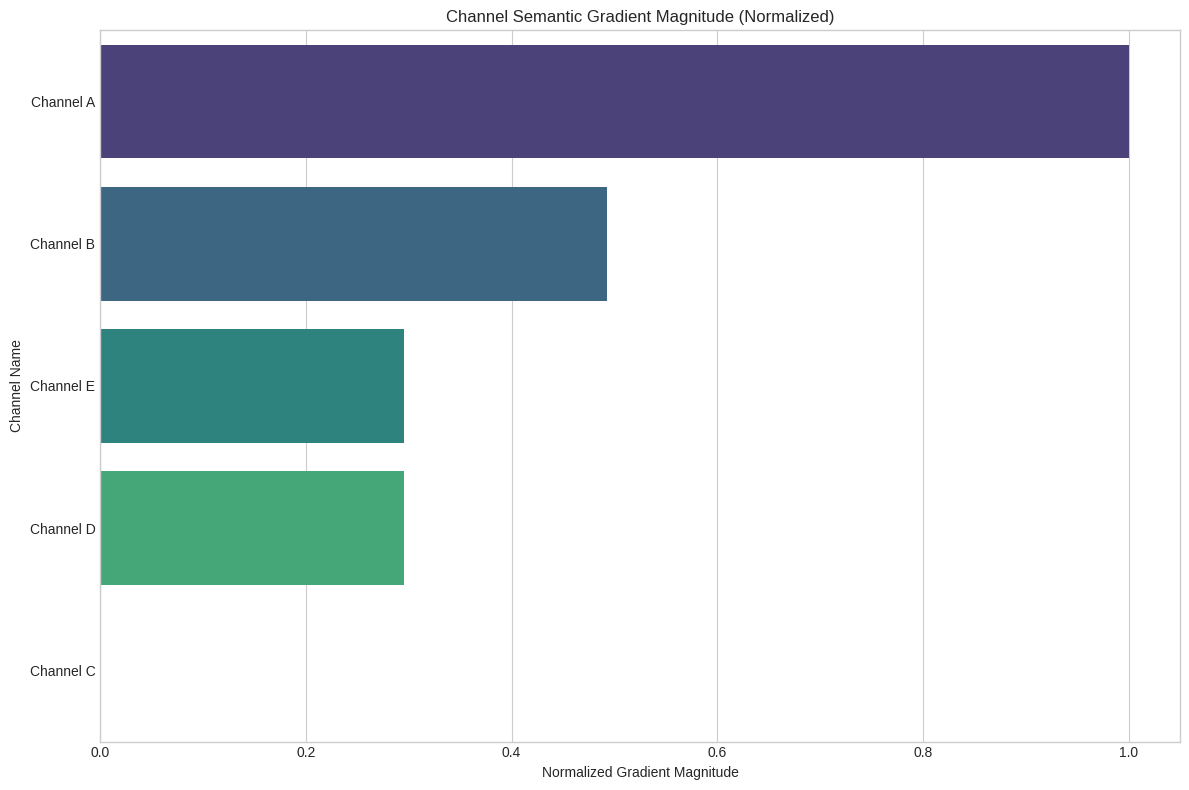

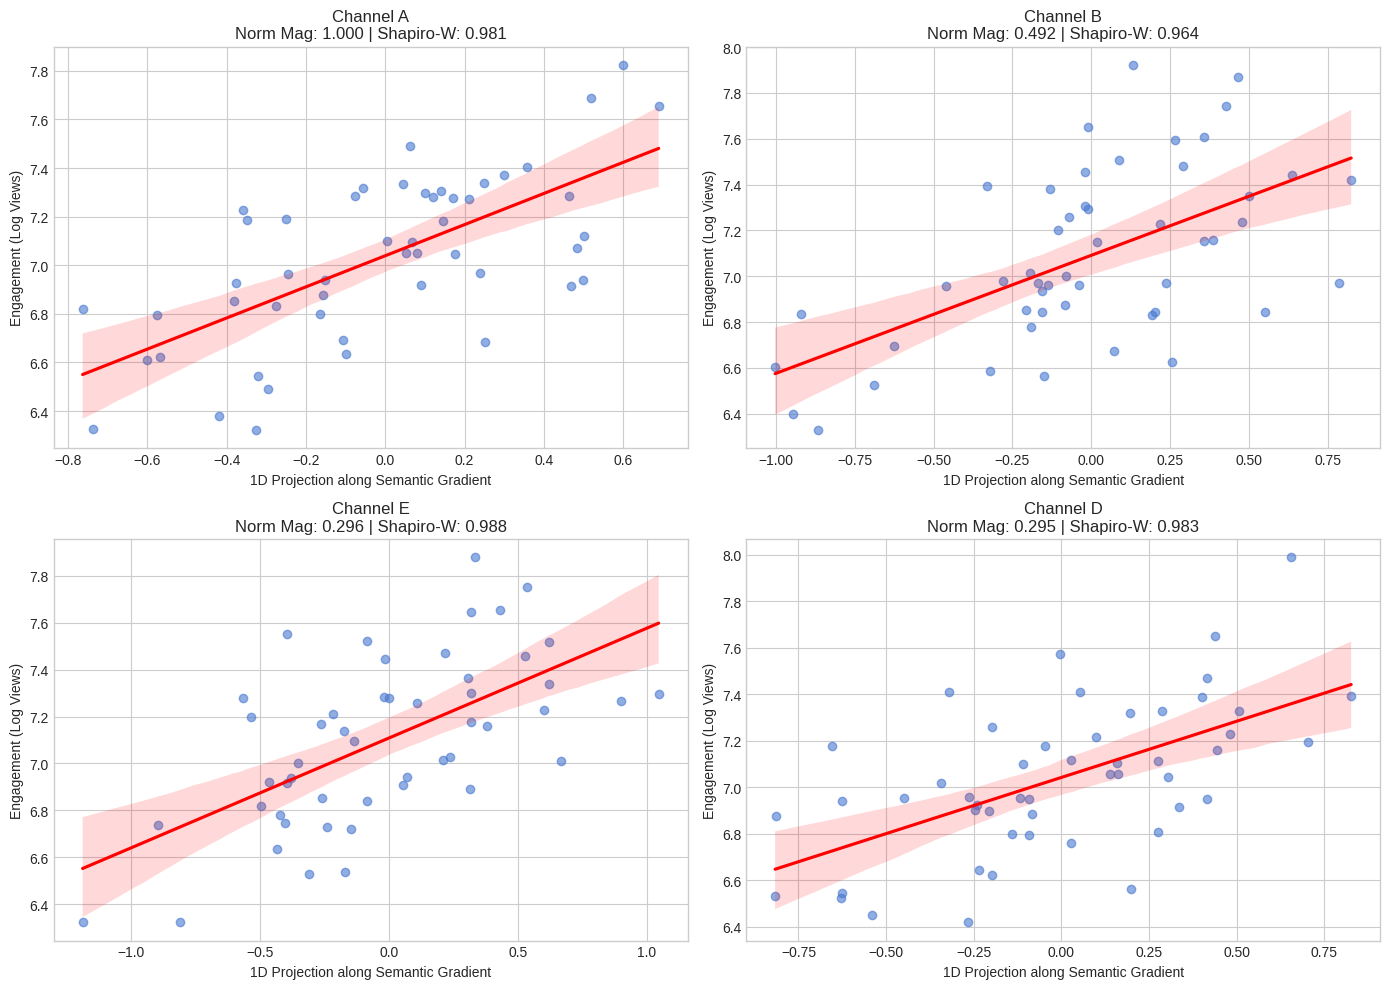

In [5]:
if not df.empty and 'metrics_df' in locals() and not metrics_df.empty:
    # 1. Bar chart of Normalized Gradient Magnitude
    plt.figure(figsize=(12, 8))
    sns.barplot(data=metrics_df, x='gradient_magnitude_normalized', y='channel_name', palette='viridis')
    plt.title('Channel Semantic Gradient Magnitude (Normalized)')
    plt.xlabel('Normalized Gradient Magnitude')
    plt.ylabel('Channel Name')
    plt.tight_layout()
    plt.show()

    # 2. Scatter plots for top representative channels (by gradient magnitude)
    top_channels = metrics_df['channel_name'].head(4).tolist()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, channel_name in enumerate(top_channels):
        if i >= 4:
            break
        ax = axes[i]
        channel_data = df[df['channel_name'] == channel_name]

        sns.regplot(
            data=channel_data,
            x='gradient_projection',
            y='log_views',
            ax=ax,
            scatter_kws={'alpha':0.6},
            line_kws={'color':'red'}
        )
        norm_mag = metrics_df.loc[metrics_df['channel_name'] == channel_name, 'gradient_magnitude_normalized'].values[0]
        shapiro_w = metrics_df.loc[metrics_df['channel_name'] == channel_name, 'normality_shapiro_w'].values[0]
        
        ax.set_title(f'{channel_name}\nNorm Mag: {norm_mag:.3f} | Shapiro-W: {shapiro_w:.3f}')
        ax.set_xlabel('1D Projection along Semantic Gradient')
        ax.set_ylabel('Engagement (Log Views)')

    plt.tight_layout()
    plt.show()

